In [43]:
import importlib
import pandas as pd
import numpy as np
import re
from pathlib import Path

import functions
importlib.reload(functions)
from functions import *

df_1111 = pd.read_csv("AI_Lit_Que_1111.csv")
df_1204 = pd.read_csv("AI_Lit_Que_1204.csv")

# add source/course label
df_1111["course"] = "1111"
df_1204["course"] = "1204"

print(df_1111.shape, df_1204.shape)


(118, 37) (23, 37)


-----
# EDA
## Descriptive statistics

### Mean comparison

#### SES

- Class 1111 is very slightly below the pooled SES average
- Class 1204 is slightly above the pooled SES average

The difference is present but not large in raw standardized units.

- *Skew < 0*: SES is somewhat left-skewed, especially in 1204.
  More observations are clustered on the higher side,
  with a tail toward lower SES-index values.

#### AI Literacy

- Class 1204 appears to have higher AI literacy on average than class 1111.
  The gap here is much more visible than for SES.


In [2]:
df, meta = prepare_dataset("AI_Lit_Que_1111.csv", "AI_Lit_Que_1204.csv")

# prepare_dataset is a preprocessing function defined in functions.py
construct_summary_table(df)

,sample,construct,n,mean,sd,median,iqr,skew
0,1111,SES index,118,-2.184274e-02,0.570420,0.003448,0.792470,-0.409507
1,1111,AI literacy score,118,3.490678e+00,0.409291,3.500000,0.500000,0.266702
2,1204,SES index,23,1.120627e-01,0.569433,0.235097,0.661270,-0.804122
3,1204,AI literacy score,23,3.800000e+00,0.450252,3.900000,0.750000,0.134169
4,Combined,SES index,141,-2.834612e-17,0.570388,0.020992,0.801864,-0.460321
5,Combined,AI literacy score,141,3.541135e+00,0.430128,3.500000,0.600000,0.294079


### Measurement consistency

#### SES

- SES shows **moderate** consistency across both classes
  (pooled Cronbach's α = 0.69).

#### AI Literacy

- AI literacy shows **low** consistency across both classes
  (pooled Cronbach's α = 0.52; even lower in 1111).

The AI literacy items do not appear to function as a highly homogeneous
single scale in this sample.


In [35]:
reliability_table(df, meta)

,sample,construct,alpha,n_complete
0,1111,SES index ingredients,0.689986,118
1,1111,AI literacy score,0.466021,118
2,1204,SES index ingredients,0.739366,23
3,1204,AI literacy score,0.624770,23
4,Combined,SES index ingredients,0.693905,141
5,Combined,AI literacy score,0.523376,141


### Effect sizes: Two-sided Mann–Whitney U test

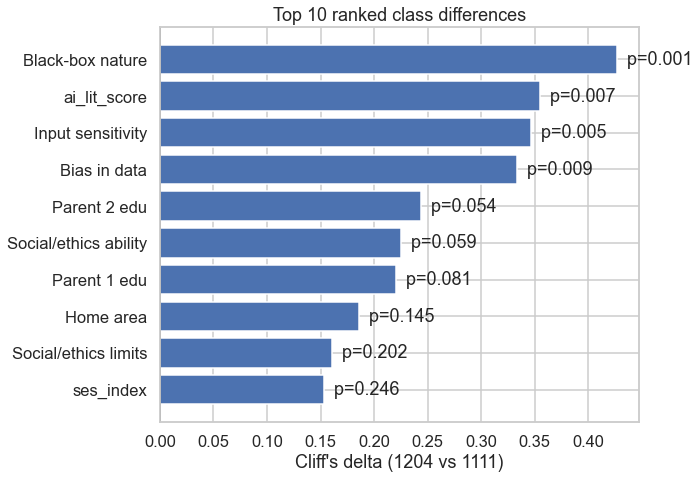

In [36]:
eff = effect_size_table(df, meta)
plot_ranked_effect_sizes(eff, top_n=10)

- Class 1204 tends to score higher than class 1111 on several AI literacy
  components, especially the more conceptual items.
- By contrast, the SES differences are weaker and mostly not statistically
  convincing.


## Visualizations
### Item profiles

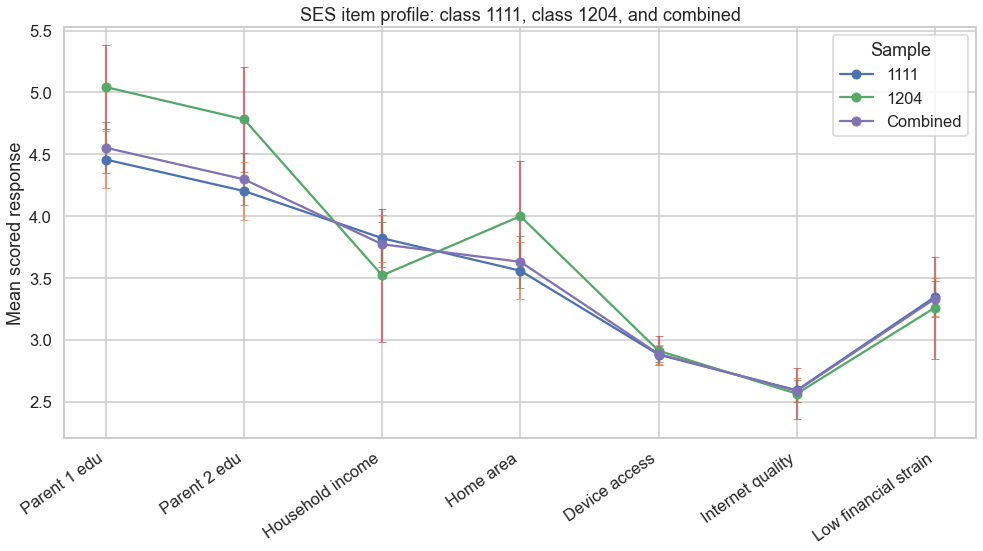

In [37]:
plot_item_profile(df, meta, construct="SES")

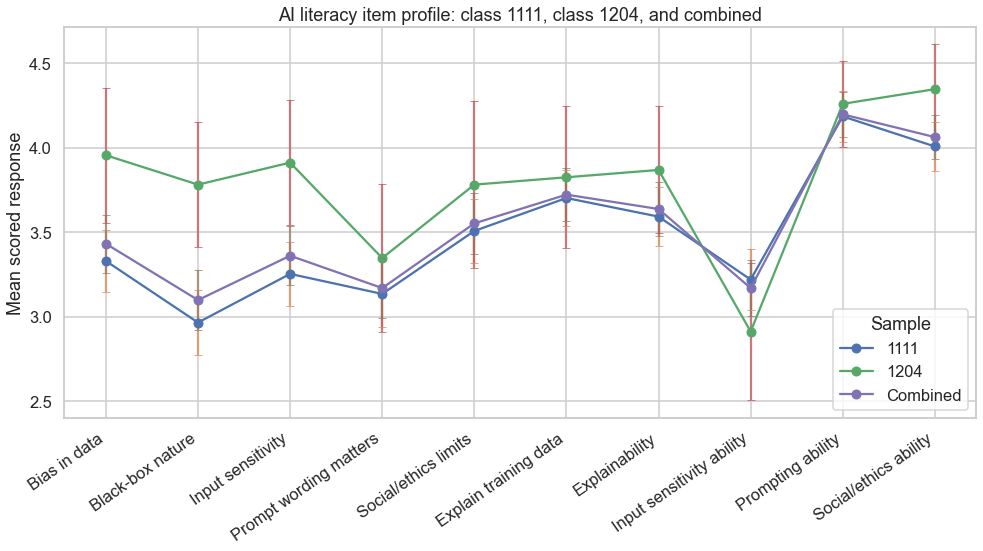

In [38]:
plot_item_profile(df, meta, construct="AI")

### Distribution of composite scores

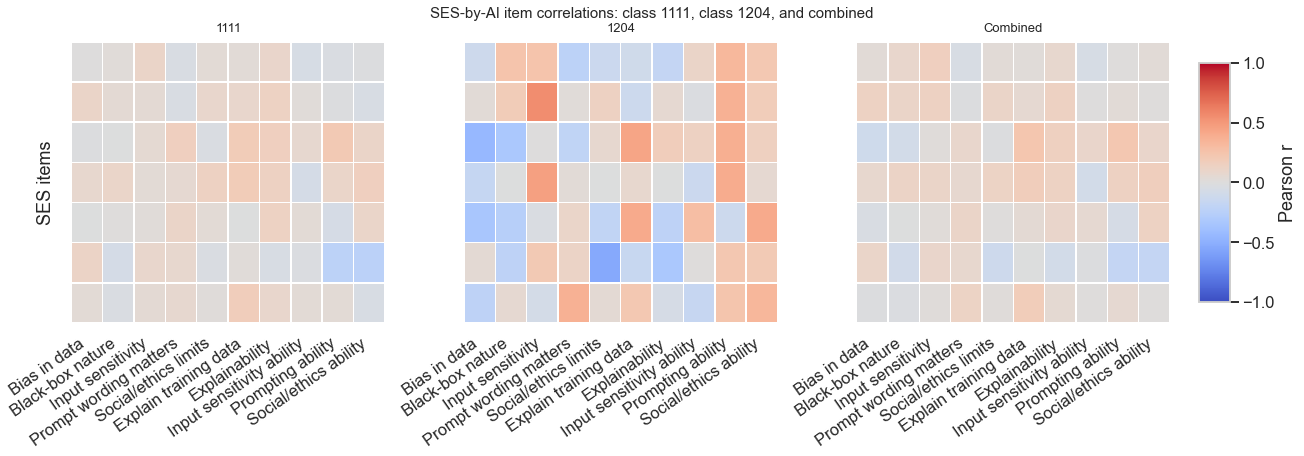

In [39]:
plot_ses_ai_correlation_heatmaps(df, meta)

- In the pooled sample, most correlations are weak to modest, with a tendency
  toward small positive associations rather than a single dominant pattern.
- The 1204 panel shows more extreme values, but given the much smaller
  subgroup size, those correlations are likely less stable.


-----
# SES Effect on AI Literacy (No mediation)

$$\text{AI literacy} = \beta_0 + \beta_1 \text{SES} + \varepsilon$$

In [3]:
run_total_effect_models(df, ses_cols="ses_index", ai_cols="ai_lit_score")

,sample,ses_dimension,ai_outcome,beta_ses_std,p_hc3,ci_low_95,ci_high_95,r_squared,spearman_rho,spearman_p
0,Combined,ses_index,ai_lit_score,0.195893,0.01,0.046838,0.344948,0.038374,0.201231,0.016723


- In the **combined sample**, SES shows a small but statistically supported
  positive association with AI literacy. Students with higher SES tend to
  have slightly higher AI literacy scores.
  
- In **class 1111**, the estimated SES effect is again positive and modest,
  and the result is statistically significant.
- In **class 1204**, the estimated effect is also positive, but highly
  uncertain and not statistically supported — most likely due to the much
  smaller sample size rather than evidence that no relationship exists.

The effect size is not large. In both 1111 and the combined sample, a one
standard deviation increase in SES is associated with only about a 0.2 SD
increase in AI literacy.

The explained variance is low (R² ≈ 0.04), meaning SES accounts for only a
small part of the variation in AI literacy. SES appears to matter, but is
clearly not the only factor.

- The Spearman correlations are also positive in 1111 and in the combined
  sample, supporting the same conclusion from a rank-based perspective.


# Exploratory Factor Analysis (EFA) 

## EFA for AI Literacy

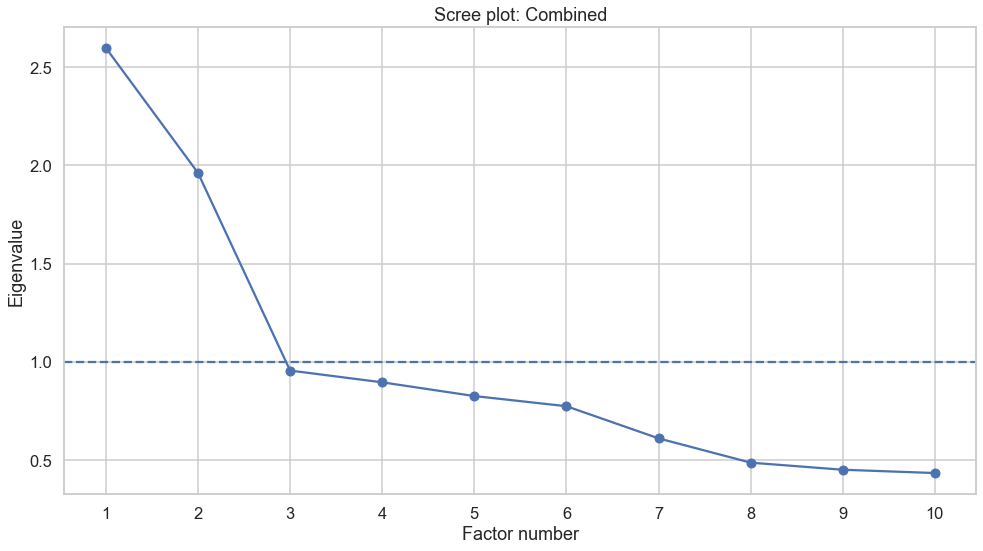

In [4]:
ai_efa_items = [
    "ai_concept_data_bias_scored_num",
    "ai_concept_blackbox_scored_num",
    "ai_concept_input_variation_scored_num",
    "ai_concept_prompt_wording_scored_num",
    "ai_concept_social_ethics_scored_num",
    "ai_ability_training_data_scored_num",
    "ai_ability_explainability_scored_num",
    "ai_ability_input_sensitivity_scored_num",
    "ai_ability_prompting_scored_num",
    "ai_ability_social_ethics_scored_num",
]

df_ai = df.copy()
diag_combined, kmo_items_combined = efa_diagnostics(df_ai, "Combined", ai_efa_items)
eig_combined = run_scree_analysis(df_ai, "Combined", ai_efa_items)
eig_combined

- The eigenvalues support a two-factor modeling. 2 principal components have eigenvalues > 1.

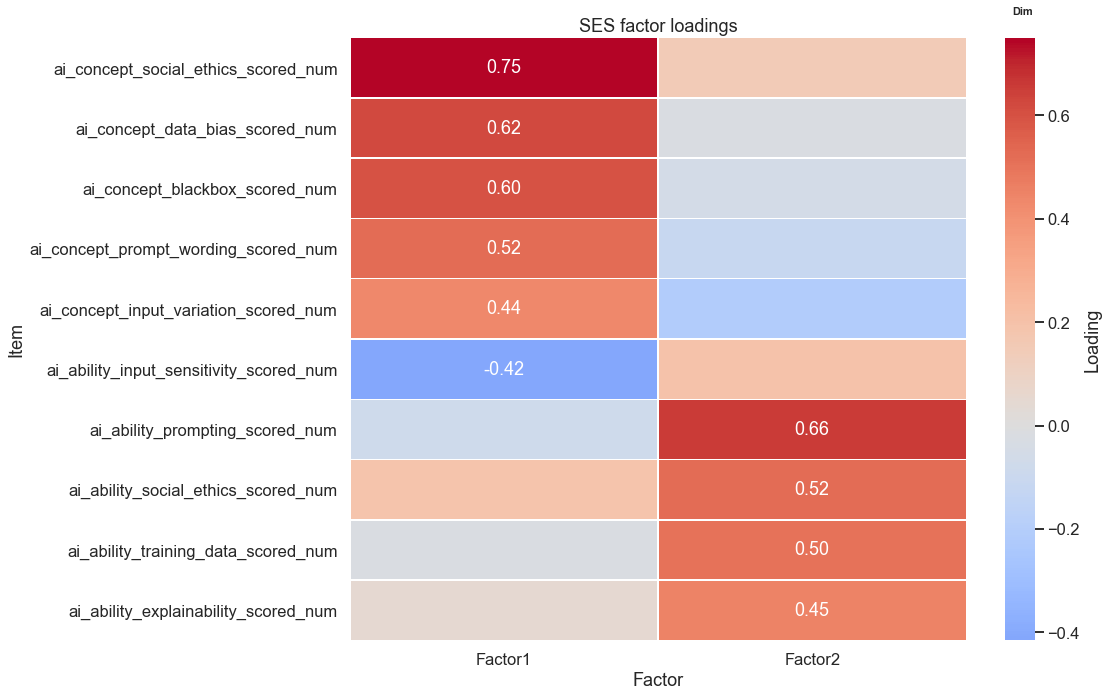

In [9]:
fa_combined, d_combined, loadings_combined, variance_combined = fit_efa(
    df=df_ai,
    sample="Combined",
    items=ai_efa_items,
    n_factors=2,
    rotation="oblimin"
)

plot_loading_heatmap(loadings_combined, cutoff=0.30, title="SES factor loadings")

- *Factor 1 is dominated by the conceptual items*: data bias, black-box nature, input variation, prompt wording, and especially social/ethics limits all load positively on this factor. 

That means Factor 1 can be interpreted as something like conceptual AI understanding

- *Factor 2 is dominated by the self-reported competence items*: explaining training data, explainability, prompting ability, and social/ethics ability load on this factor.

Factor 2 looks like self-reported AI ability/confidence.



## SES variables

### Special test for 'other' school vs non-other school


- Two sided t-test:

$$
H_a: \mu_{\text{other school}} \neq \mu_{\text{non-other school}}
$$

In [18]:
school_others_ses_ttest(df).round(3)

,metric,n_others,mean_diff_others_minus_nonothers,t_stat,p-value,cohens_d
0,Parent 2 education,17,1.066,4.082,0.000,0.866
1,Parent 1 education,17,0.909,3.422,0.002,0.753
2,Home area,17,0.486,1.769,0.090,0.387
3,SES index,17,0.198,1.425,0.169,0.348
4,Device access,17,-0.205,-1.405,0.177,-0.522
5,Low financial strain,17,-0.045,-0.202,0.842,-0.050
6,Household income,17,-0.009,-0.032,0.975,-0.009
7,Internet quality,17,-0.000,-0.003,0.998,-0.001


- Conclusion:

There is no significant difference between 'other school' and 'non-other school' in terms of most SES metrics except Parent education. 

- *Assigns the 'Others school' group to the known group with the smallest Euclidean distance*

Uses the students in the 3 known school groups as reference. Computes the centroid (mean SES profile) for each known group and the centroid for the 'Others school' group. 


### EFA for SES

- new feature: Space_per_person

- quantified school type and housing type

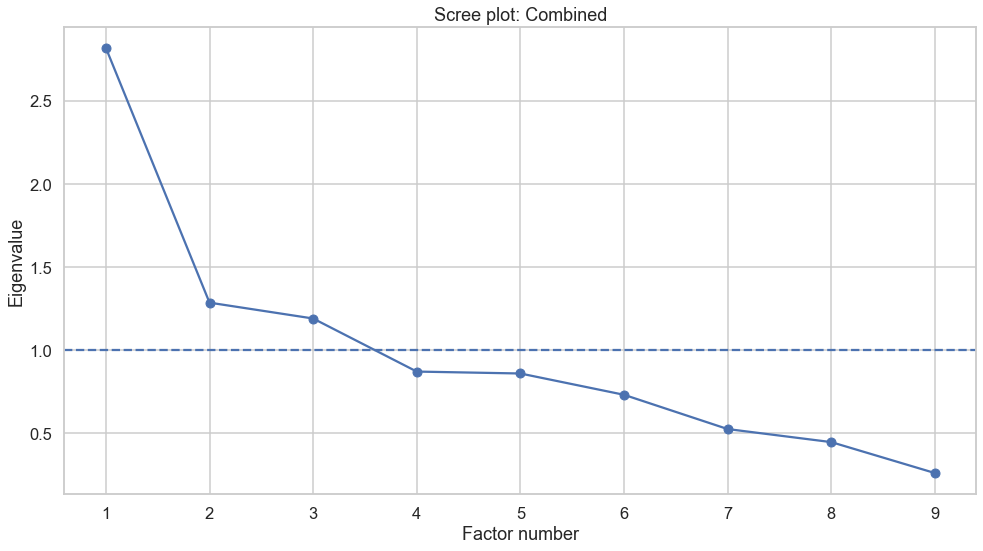

In [37]:
# Language SES is not included here

df_ses = add_ses_space_house_variables(df)

ses_efa_items_2dim = [
    "ses_parent1_edu_num",
    "ses_parent2_edu_num",
    "ses_device_access_scored_num",
    "ses_household_income_num",
    "ses_financial_constraint_scored_num",
    "ses_space_per_person",
    "ses_housing_type_ord",
    "ses_internet_quality_scored_num",
    "ses_school_type_ord",
]

diag_ses_combined, kmo_ses_combined = efa_diagnostics(df_ses, "Combined", ses_efa_items_2dim)
eig_ses_combined = run_scree_analysis(df_ses, "Combined", ses_efa_items_2dim)


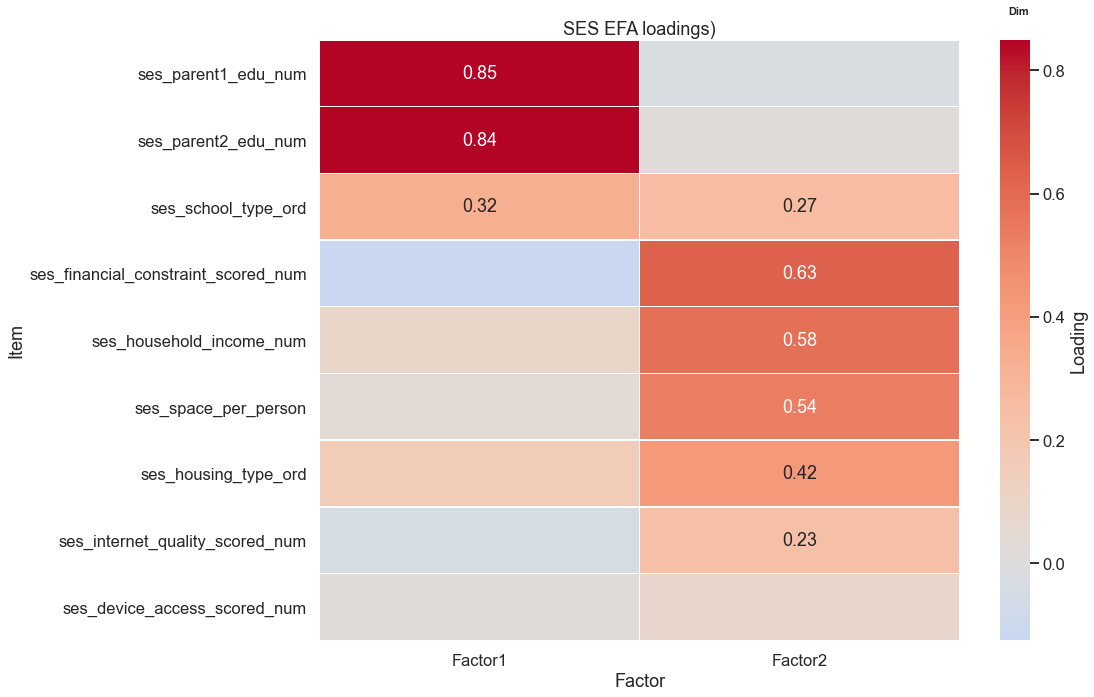

In [40]:
fa_ses2, d_ses2, loadings_ses2, variance_ses2 = fit_efa(
    df=df_ses,
    sample="Combined",
    items=ses_efa_items_2dim,
    n_factors=2,
    rotation="oblimin"
)

plot_loading_heatmap(
    loadings_ses2,
     cutoff=0.2,
    title="SES EFA loadings)"
)

- We may probably try two dimentions in SES

#### Conclusion
- Based on the EFA, SES can be treated as two dimensions:

1. Family / institutional background
	ses_parent1_edu_num 
	ses_parent2_edu_num 
	ses_school_type_ord 

2. Material resources
	ses_household_income_num 
	ses_financial_constraint_scored_num 
	ses_space_per_person 
	ses_housing_type_ord 

AI literacy is better represented by two related but distinct components: 
1. Conceptual understanding 

2. Ability/confidence. 


- Refiting the simple linear model using the factor scores:
It returns a disappointing result: the SES factor is not significantly associated with either AI factor, and the effect sizes are very small. 


------
# Mediator analysis

## Mediator pairs

Each mediator is measured by two different questions. We should check the consistency of these pairs before using them in mediation analyses. 

In [48]:
mediator_reliability = mediator_reliability_table(df, mediator_map)
mediator_reliability

,sample,mediator,n_complete,spearman_rho,alpha_2item
0,1111,conceptual_exposure,118,0.292140,0.486054
1,1111,practical_ai_use,118,0.223236,0.379432
2,1111,learning_ecology,118,0.147209,0.274513
3,1111,language_load,118,0.601679,0.759845
4,1111,epistemic_stance,118,0.320206,0.564601
5,1204,conceptual_exposure,23,0.392293,0.567944
6,1204,practical_ai_use,23,0.367887,0.528373
7,1204,learning_ecology,23,0.399625,0.622269
8,1204,language_load,23,0.625154,0.779258
9,1204,epistemic_stance,23,0.360713,0.406300


- rho >= 0.30 , alpha > 0.5 means acceptable for a 2-item pair 

- Most pairs show at least a modest positive association (by rho and Alpha 2 )

- The weakest pair is learning_ecology (rho ≈ 0.18, p ≈ 0.028). 
This is still positive, but the association is fairly small. That suggests the two items may not be capturing exactly the same thing, even if they belong to the same broad domain.


#### Add composite mediator scores (averaging two items)

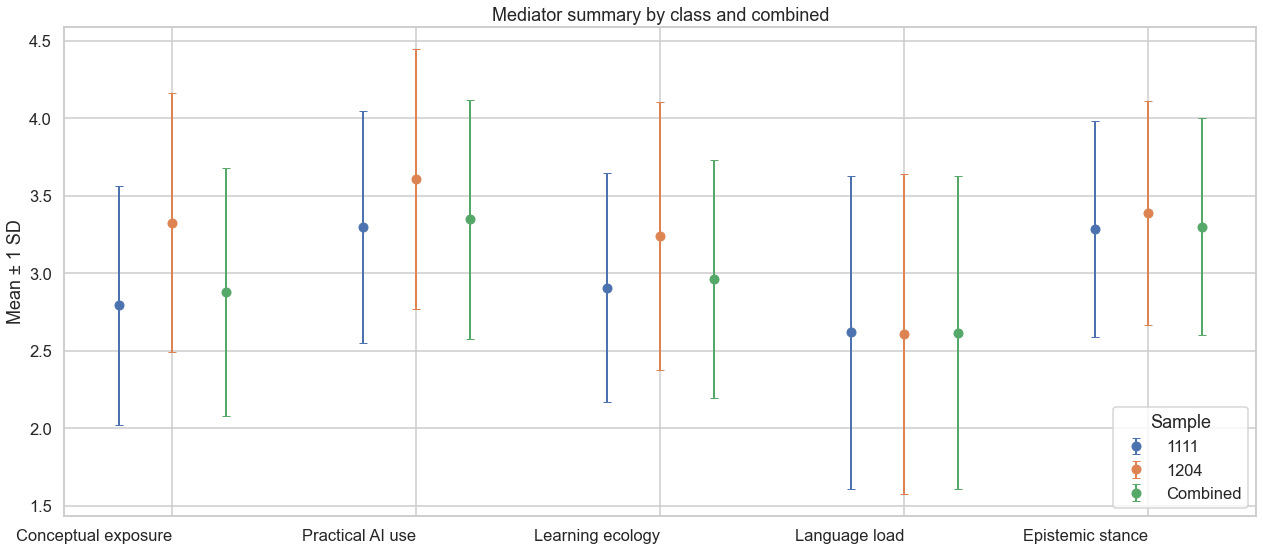

In [14]:
df_med = add_mediator_composites(df, mediator_map)

# mediators table
med_summary = mediator_summary_table(df_med)
plot_mediator_summary(med_summary, errorbar="sd")

## Indirect Effect Model specification
- Mediation models (a path)

$$\text{Mediator} = \alpha_0 + a \cdot SES + \varepsilon_M$$

- Outcome model (b path)

$$\text{AI literacy} = \beta_0 + c' \cdot SES + b \cdot \text{Mediator} + \varepsilon_Y$$

- Indirect effect ($a \cdot b$): greater than zero when a and b are both positive (or both negative)

- Total effect ($c = c' + a \cdot b$)

- Indirect effect coefficient and confidence interval are estimated using bootstrapping

- 2 * SES -> 5* mediators -> 2 * AI factors = 20 mediation models in total


## Direct effect of selected split points of SES on AI literacy

In [ ]:
# merge factor scores into mediator dataframe
df_analysis = add_ses_ai_factor_scores(
    df_base=df_med,
    ai_df=df,
    ai_items=ai_efa_items,
    ai_fa=fa_combined,
    ses_df=df_ses,
    ses_items=ses_efa_items_2dim,
    ses_fa=fa_ses2
)



,sample,ses_dimension,ai_outcome,beta_ses_std,p_hc3,ci_low_95,ci_high_95,r_squared,spearman_rho,spearman_p
0,Combined,ses_factor1_score,ai_factor1_score,0.047612,0.542638,-0.105662,0.200885,0.002267,0.048846,0.565161
1,Combined,ses_factor1_score,ai_factor2_score,0.179701,0.036467,0.011316,0.348086,0.032293,0.242012,0.003837
2,Combined,ses_factor1_score,ai_lit_score,0.197303,0.010592,0.046002,0.348604,0.038928,0.204482,0.015006
3,Combined,ses_factor2_score,ai_factor1_score,0.176354,0.032309,0.014879,0.337829,0.031101,0.189118,0.024706
4,Combined,ses_factor2_score,ai_factor2_score,0.153284,0.022160,0.021954,0.284613,0.023496,0.180156,0.032540
5,Combined,ses_factor2_score,ai_lit_score,0.268104,0.000249,0.124679,0.411530,0.071880,0.280906,0.000741


In [95]:
mediation_results_2ses = run_all_simple_mediations(
    df_analysis,
    x=["ses_factor1_score", "ses_factor2_score"],
    mediators=mediator_vars,
    outcomes=["ai_factor1_score", "ai_factor2_score"],
    sample_list=["Combined"],
    n_boot=3000,
    seed=2026
)

mediation_results_2ses["ses_dimension"] = mediation_results_2ses["ses_dimension"].map(ses_label_map).fillna(mediation_results_2ses["ses_dimension"])
mediation_results_2ses["outcome"] = mediation_results_2ses["outcome"].map(outcome_label_map).fillna(mediation_results_2ses["outcome"])
mediation_results_2ses["mediator"] = mediation_results_2ses["mediator"].map(mediator_label_map).fillna(mediation_results_2ses["mediator"])

### The indirect-effect forest plot 

- The a path is SES -> Mediator_i

- The b path is the Mediator_i -> AI literacy while controlling for SES.

 Each point is the estimated indirect effect a $\times$ b, and the horizontal line is the bootstrap 95% confidence interval. If the interval stays on one side of zero, that mediator shows clearer evidence of an indirect pathway.

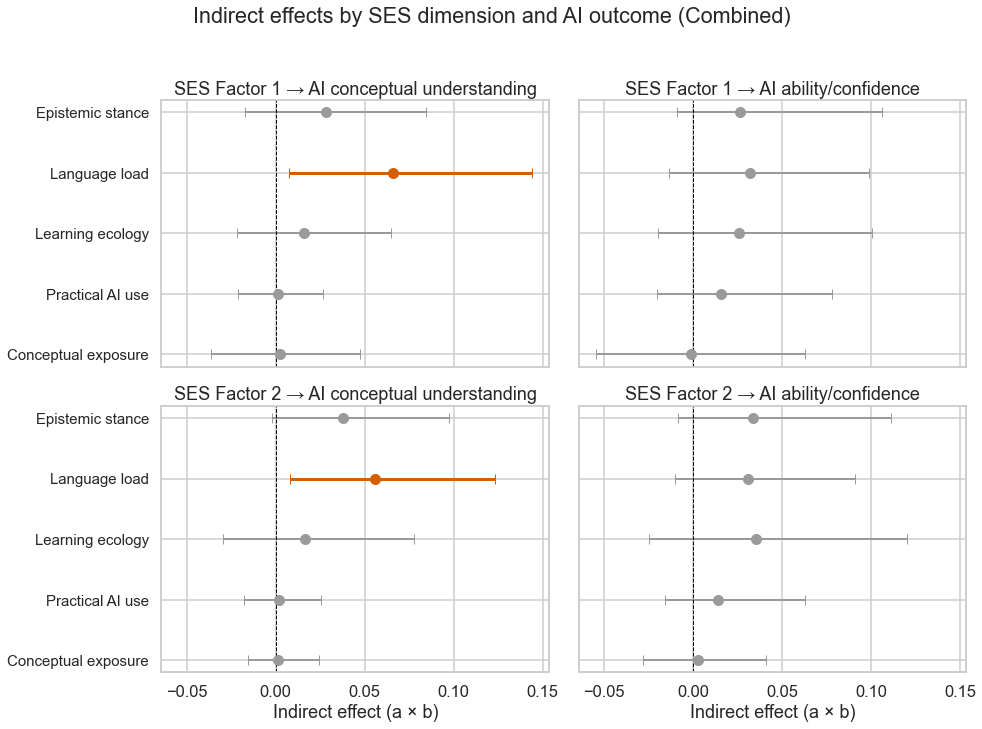

In [96]:
plot_indirect_effect_forest(mediation_results_2ses, sample="Combined")

### a–b path plot 

We need both paths to get a meaningful indirect effect, because mediation only exists when SES is linked to the mediator and the mediator is linked to AI literacy.


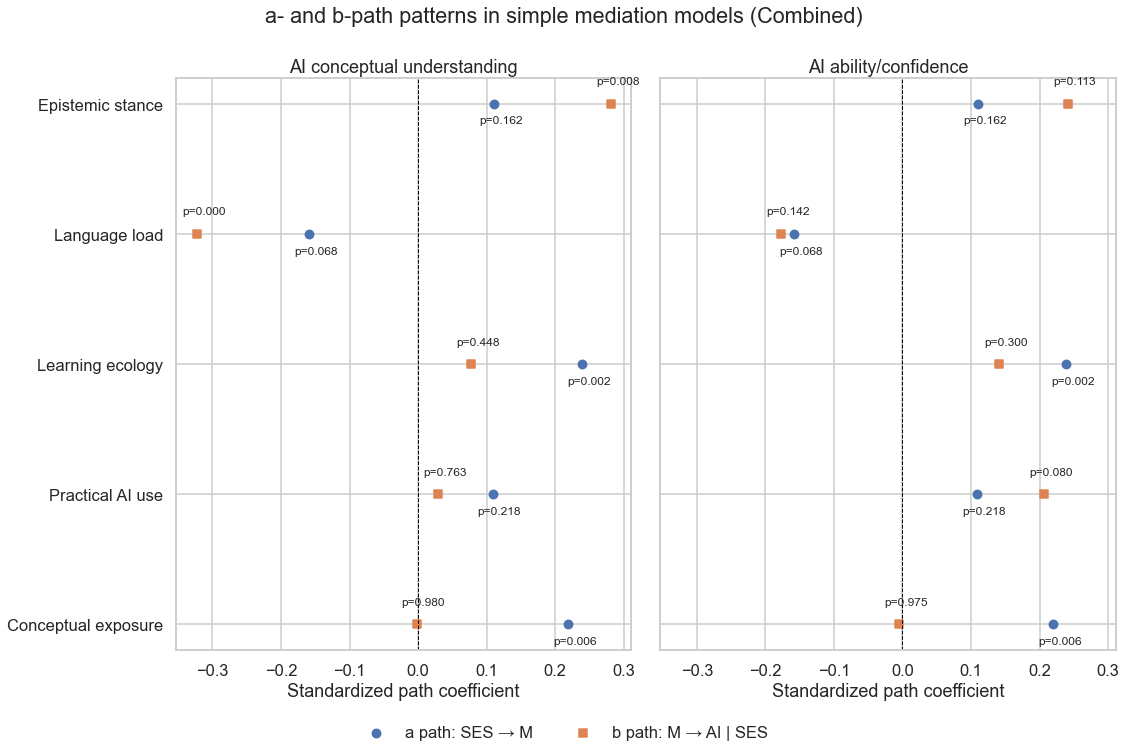

In [ ]:
plot_a_b_paths(mediation_results)

### Main results

- 1204 is too unstable to support much interpretation because of the very small sample The combined sample and 1111 show more interpretable signals.

- The strongest mediation evidence is for Language load → AI conceptual understanding.

- A secondary, weaker candidate is Epistemic stance → AI conceptual understanding.

- For AI ability/confidence, none of the mediators shows a clearly convincing indirect effect.

Strong significant mediation: 

1. Higher SES → Less language burden → Better conceptual AI understanding

2. Higher SES → Stronger epistemic stance → Better conceptual AI understanding

Expect but weak results

1. More SES → more practical AI use → more AI ability/confidence
The evidence is weak, mainly because the a_path is not strong enough.

2. Conceptual exposure does not appear to be the mechanism linking SES to AI literacy in these simple mediation models.

------
# Check 4 left-out SES categories 

The following 4 variables are treated as non-ordinal SES indicators and are not included in the main SES factor:
- Housing type
- School type
- Household size
- Home language


In [53]:
check_groups = [None, "home_language","school", "housing", "household_size"]

direct_verify = pd.concat(
    [verify_direct_effect(df_analysis, check_group=g, sample="Combined") for g in check_groups],
    ignore_index=True
)

med_verify = pd.concat(
    [verify_one_mediation(df_analysis, "language_load_score", "ai_factor1_score", check_group=g, sample="Combined")
     for g in check_groups],
    ignore_index=True
)

## Direct effect from SES -> AI literacy

The coefficient $\beta_1$ in $\text{AI literacy} = \beta_0 + \beta_1 \text{SES} + \varepsilon$:
- about 0.19 with no extra check
- about 0.19 after controlling for home language
- about 0.19 after controlling for household size
- shrink to 0.16 with school
- shrink to 0.14 with housing

The main effect of SES -> AI literacy is fairly stable to home-language and household-size verification. Part of the SES effect overlaps with school and housing context.


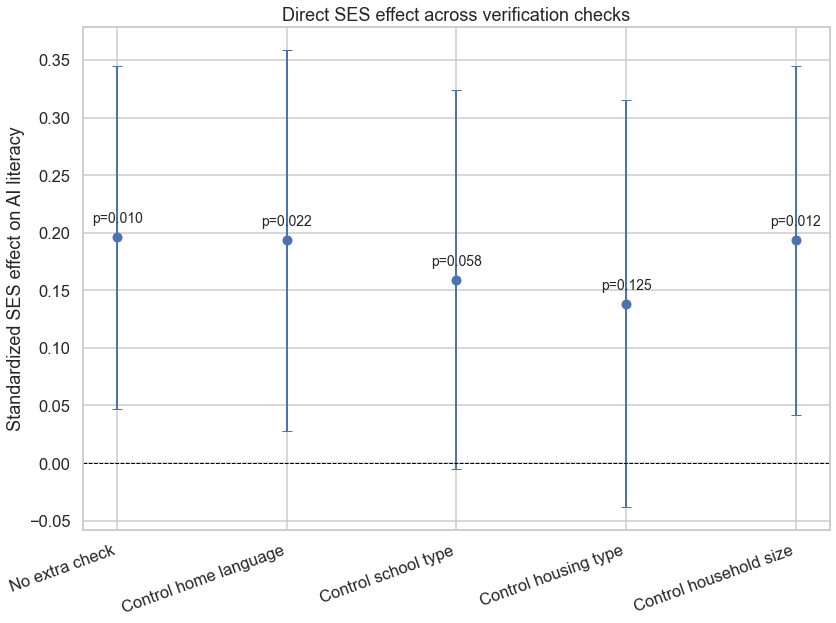

In [100]:
plot_direct_effect_verification(direct_verify)

## Mediating effects of SES on AI literacy through left-out SES categories

### Mediator Language load while controlling 4 left-out SES categories

Strongest mediating effect: 

SES → lower language load → better AI conceptual understanding

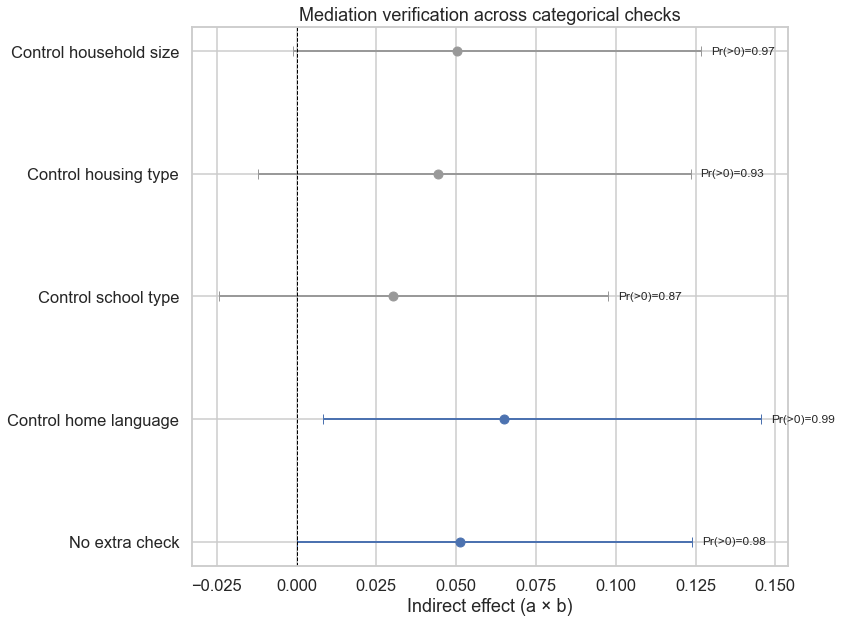

In [98]:
med_verify
plot_mediation_verification(med_verify)

Result:

1. The indirect effect: SES -> language load -> AI conceptual understanding still positive

-  a-path stays negative (higher SES -> lower language load)
-  b-path stays negative (lower language load -> better conceptual AI understanding)

2. The indirect effect increases from about 0.051 to 0.065 controling for home language

- bootstrap CI stays above zero and proportion positive rises to about 0.99
- the language-load pathway is not simply a proxy for home-language background.

In plain language:
	•	it is not just that some students speak different languages at home
	•	it is that SES is still related to language burden, and language burden is still related to AI conceptual understanding, even after taking home-language background into account


### Mediator Epistemic stance while controlling 4 left-out SES categories

- Significant but weaker mediating effect:

SES -> epistemic stance -> AI conceptual understanding

1. a-path is the weaker: SES is only weakly related to epistemic stance

2. b-path is stronger: stronger epistemic stance is related to better AI conceptual understanding after controlling for SES



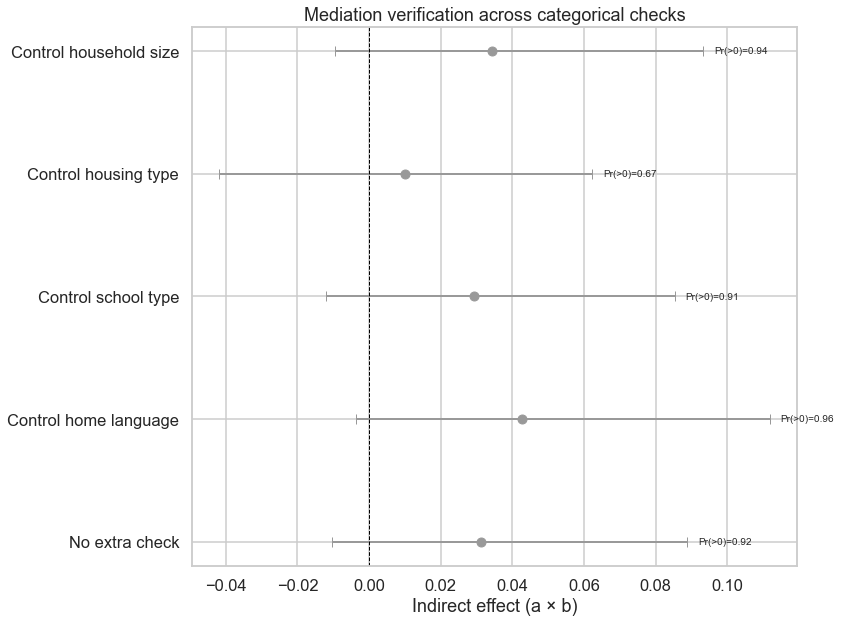

In [ ]:
med_verify_epistemic = pd.concat(
    [verify_one_mediation(df_analysis, "epistemic_stance_score", "ai_factor1_score", check_group=g, sample="Combined")
     for g in check_groups],
    ignore_index=True
)
plot_mediation_verification(med_verify_epistemic)


------
# Check 3 weaker mediators

## Overview of all mediators
- Practical AI use → AI ability/confidence looks like the most promising of the weak paths

- Learning ecology looks weak partly because the measurement is weak. 


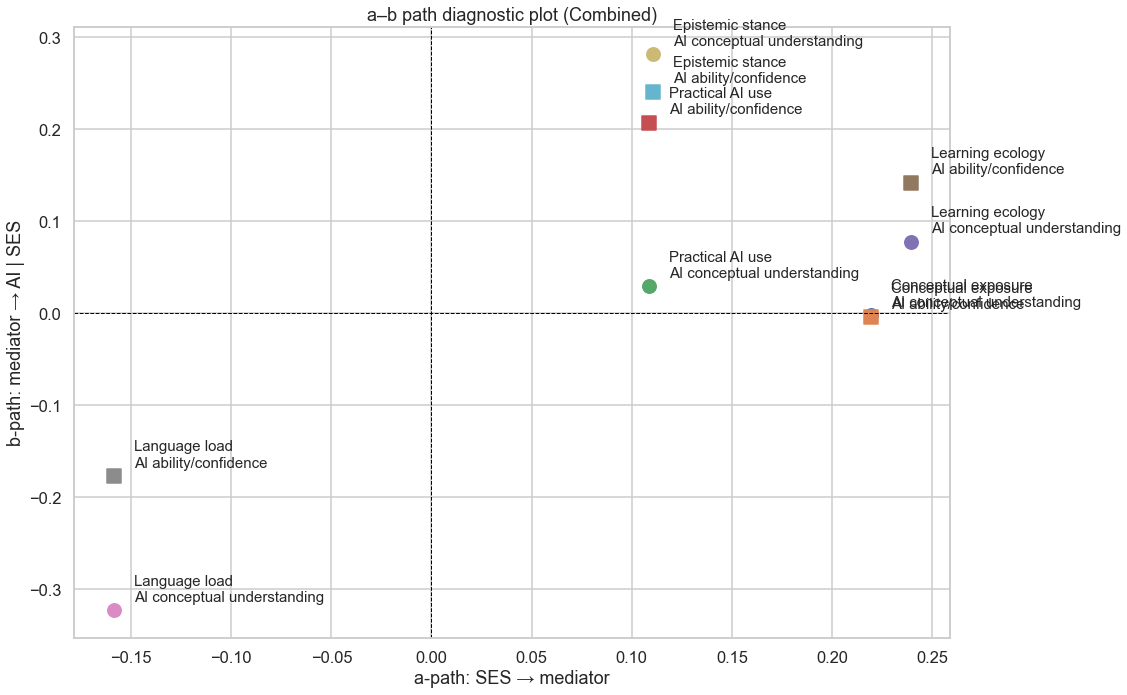

In [109]:
diag_paths = diagnose_mediation_paths(mediation_results) #result table
# diag_paths[[
#     "sample", "mediator", "outcome",
#     "a_path", "a_p", "b_path", "b_p",
#     "indirect_ab", "indirect_ci_low_95", "indirect_ci_high_95",
#     "diagnosis"
# ]].round(3)

plot_ab_diagnostic(mediation_results, sample="Combined")

- Conceptual exposure is SES-related, but it is not the mechanism carrying SES into AI literacy.
   This mediator looks more like a background experience variable than an active explanatory pathway for conceptual AI understanding.

   (SES -> Conceptual exposure exists but exposure -> AI literacy | SES is almost zero)

   $\textbf{This result is reasonable. We may not put Conceptual exposure into further analysis.}$

In [67]:
compare_one_mediator_across_outcomes(mediation_results, "Practical AI use", sample="Combined").round(3)

,sample,mediator,outcome,a_path,a_p,b_path,b_p,indirect_ab,indirect_ci_low_95,indirect_ci_high_95,prop_ab_positive
23,Combined,Practical AI use,AI ability/confidence,0.109,0.218,0.207,0.080,0.022,-0.009,0.091,0.890
22,Combined,Practical AI use,AI conceptual understanding,0.109,0.218,0.029,0.763,0.003,-0.026,0.031,0.584


In [68]:
compare_one_mediator_across_outcomes(mediation_results, "Learning ecology", sample="Combined").round(3)

,sample,mediator,outcome,a_path,a_p,b_path,b_p,indirect_ab,indirect_ci_low_95,indirect_ci_high_95,prop_ab_positive
25,Combined,Learning ecology,AI ability/confidence,0.239,0.002,0.141,0.300,0.034,-0.022,0.112,0.866
24,Combined,Learning ecology,AI conceptual understanding,0.239,0.002,0.078,0.448,0.019,-0.030,0.076,0.782


In [77]:
compare_one_mediator_across_outcomes(mediation_results, "Conceptual exposure", sample="Combined").round(3)

,sample,mediator,outcome,a_path,a_p,b_path,b_p,indirect_ab,indirect_ci_low_95,indirect_ci_high_95,prop_ab_positive
21,Combined,Conceptual exposure,AI ability/confidence,0.219,0.006,-0.005,0.975,-0.001,-0.062,0.076,0.499
20,Combined,Conceptual exposure,AI conceptual understanding,0.219,0.006,-0.002,0.980,-0.001,-0.041,0.048,0.507


## Weak mediator: Practical AI use

- Practical AI use looks more relevant for AI ability/confidence than for conceptual understanding, but it is still weak overall. 

  a-path: SES -> practical AI use is not strong enough

- Regress each item in `practical_ai_use_items` separately against SES and AI factor2 score.

In [110]:
practical_ai_use_items = [
    "med_practical_ai_use_1_num",
    "med_practical_ai_use_2_num",
]

practical_ai_use_item_results = run_item_level_mediation(
    df_analysis,
    sample="Combined",
    x="ses_index",
    mediator_items=practical_ai_use_items,
    y="ai_factor2_score",
    n_boot=3000,
    seed=2026
)

practical_ai_use_item_results.round(3)

,sample,mediator,outcome,n,a_path,a_p,b_path,b_p,c_total,c_total_p,c_prime,c_prime_p,indirect_ab,direct_plus_indirect_check,r2_mediator_model,r2_outcome_model,indirect_boot_mean,indirect_ci_low_95,indirect_ci_high_95,prop_ab_positive
0,Combined,med_practical_ai_use_1_num,ai_factor2_score,141,0.205,0.016,0.020,0.880,0.123,0.102,0.119,0.091,0.004,0.123,0.042,0.016,0.004,-0.051,0.070,0.528
1,Combined,med_practical_ai_use_2_num,ai_factor2_score,141,-0.025,0.763,0.298,0.009,0.123,0.102,0.131,0.074,-0.007,0.123,0.001,0.104,-0.006,-0.057,0.049,0.374


- The two practical-AI-use items are pulling in different ways:

	one is SES-related but not AI-related

	the other is AI-related but not SES-related
	
	when averaging them together, we do not get a clean mediation path

## Weak mediator: Learning ecology

- Learning ecology looks weak mainly because the b-path is weak. SES does predict it, but once SES is in the model, learning ecology itself does not predict the AI outcomes strongly enough.

The other reason for the weak mediation evidence is that the composite of 2 items of it is weakly measured.(Reliability is low)


In [107]:
learning_ecology_items = [
    "med_learning_ecology_1_num",
    "med_learning_ecology_2_num",
]

learning_item_results = run_item_level_mediation(
    df_analysis,
    sample="Combined",
    x="ses_index",
    mediator_items=learning_ecology_items,
    y="ai_factor2_score",
    n_boot=3000,
    seed=2026
)

learning_item_results.round(3)

,sample,mediator,outcome,n,a_path,a_p,b_path,b_p,c_total,c_total_p,c_prime,c_prime_p,indirect_ab,direct_plus_indirect_check,r2_mediator_model,r2_outcome_model,indirect_boot_mean,indirect_ci_low_95,indirect_ci_high_95,prop_ab_positive
0,Combined,med_learning_ecology_1_num,ai_factor2_score,141,0.110,0.159,0.098,0.427,0.123,0.102,0.113,0.118,0.011,0.123,0.012,0.025,0.011,-0.018,0.057,0.750
1,Combined,med_learning_ecology_2_num,ai_factor2_score,141,0.259,0.001,0.118,0.272,0.123,0.102,0.093,0.222,0.031,0.123,0.067,0.028,0.031,-0.020,0.100,0.872


- The b-paths (M -> AI literacy) of both items of learning ecology are weak.